# ETAPA 03 - Modelagem de IA

## Projeto: Manutenção Preditiva de "Zero-Downtime"

**Disciplina:** Ciência de Dados  
**Curso:** Engenharia de Controle e Automação  
**Grupo:** E  

### Integrantes
- Bruno Alves Guirado
- Guilherme Nascimento
- Guilherme Fernando
- Lucas Guedes
- Pedro Henrique Mateus

### Dataset utilizado
**AI4I 2020 Predictive Maintenance Dataset**

## 1. Objetivo da Etapa

Esta etapa tem como objetivo desenvolver, treinar e avaliar modelos de Machine Learning capazes de prever a ocorrência de falhas em máquinas industriais a partir de variáveis operacionais do dataset AI4I 2020.

A proposta busca transformar os achados da Análise Exploratória de Dados (EDA) em uma solução prática de classificação supervisionada, permitindo identificar se uma máquina apresenta risco de falha com base em seus dados operacionais.

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

plt.rcParams["figure.figsize"] = (8, 5)
sns.set_style("whitegrid")

## 2. Carregamento dos Dados

Nesta etapa, carregamos a base tratada gerada após o processo de ETL, que será utilizada na modelagem preditiva.

In [15]:
df = pd.read_csv("../data/processed/dados_tratados.csv")
df.head()

,udi,product_id,type,air_temperature_[k],process_temperature_[k],rotational_speed_[rpm],torque_[nm],tool_wear_[min],machine_failure,twf,hdf,pwf,osf,rnf
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


## 3. Seleção da Variável Alvo e das Variáveis Preditoras

A variável alvo do problema é `machine_failure`, que indica a ocorrência ou não de falha da máquina.

As variáveis `udi` e `product_id` foram removidas por atuarem apenas como identificadores, sem relevância preditiva esperada.

In [16]:
features = [
    "type",
    "air_temperature_[k]",
    "process_temperature_[k]",
    "rotational_speed_[rpm]",
    "torque_[nm]",
    "tool_wear_[min]"
]

target = "machine_failure"

X = df[features]
y = df[target]

print("Dimensão de X:", X.shape)
print("Dimensão de y:", y.shape)

Dimensão de X: (10000, 6)
Dimensão de y: (10000,)


## 4. Separação entre Treino e Teste

A base foi dividida em conjuntos de treino e teste, preservando a proporção das classes por meio da estratificação.

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Treino:", X_train.shape, y_train.shape)
print("Teste:", X_test.shape, y_test.shape)

Treino: (8000, 6) (8000,)
Teste: (2000, 6) (2000,)


## 5. Pré-processamento

Como a variável `type` é categórica e as demais são numéricas, foi construído um pipeline de pré-processamento com:

- OneHotEncoder para variáveis categóricas;
- StandardScaler para variáveis numéricas.

In [18]:
categorical_features = ["type"]
numeric_features = [
    "air_temperature_[k]",
    "process_temperature_[k]",
    "rotational_speed_[rpm]",
    "torque_[nm]",
    "tool_wear_[min]"
]

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", StandardScaler(), numeric_features)
    ]
)

## 6. Definição dos Modelos

Foram selecionados três algoritmos de classificação para comparação:

- Regressão Logística
- Árvore de Decisão
- Random Forest

In [19]:
models = {
    "Regressão Logística": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "Árvore de Decisão": DecisionTreeClassifier(random_state=42, class_weight="balanced"),
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight="balanced"
    )
}

## 7. Treinamento e Avaliação dos Modelos

Nesta etapa, cada modelo foi treinado com os dados de treino e avaliado no conjunto de teste com base nas métricas de classificação.

In [20]:
results = []

for name, model in models.items():
    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    
    results.append({
        "Modelo": name,
        "Acurácia": accuracy_score(y_test, y_pred),
        "Precisão": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1-score": f1_score(y_test, y_pred, zero_division=0)
    })

In [21]:
results_df = pd.DataFrame(results).sort_values(by="F1-score", ascending=False)
results_df

,Modelo,Acurácia,Precisão,Recall,F1-score
1,Árvore de Decisão,0.9780,0.714286,0.588235,0.645161
2,Random Forest,0.9805,0.939394,0.455882,0.613861
0,Regressão Logística,0.8245,0.141772,0.823529,0.241901


## 8. Comparação dos Resultados

A tabela abaixo apresenta o desempenho dos modelos avaliados, permitindo comparar seus resultados e selecionar a abordagem mais adequada para o problema.

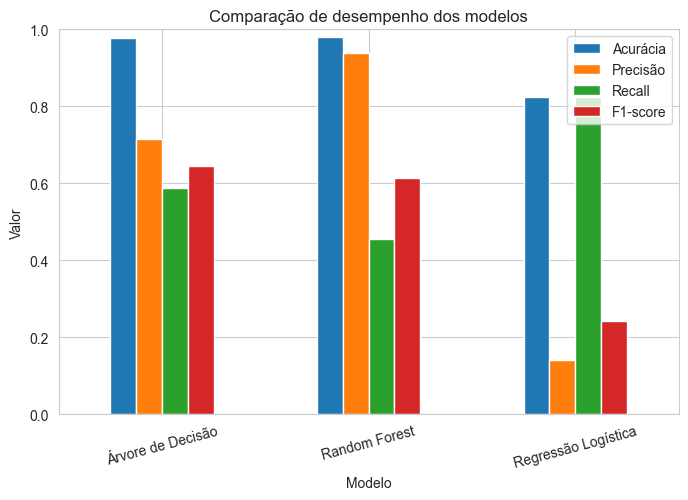

In [22]:
results_df.set_index("Modelo")[["Acurácia", "Precisão", "Recall", "F1-score"]].plot(kind="bar")
plt.title("Comparação de desempenho dos modelos")
plt.ylabel("Valor")
plt.xticks(rotation=15)
plt.ylim(0, 1)
plt.show()

## 9. Seleção do Melhor Modelo

O melhor modelo será escolhido com base principalmente no **F1-score**, por se tratar de um problema de classificação com classes desbalanceadas.

In [23]:
best_model_name = results_df.iloc[0]["Modelo"]
best_model_name

'Árvore de Decisão'

In [24]:
best_model = models[best_model_name]

best_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", best_model)
])

best_pipeline.fit(X_train, y_train)
best_y_pred = best_pipeline.predict(X_test)

## 10. Matriz de Confusão do Melhor Modelo

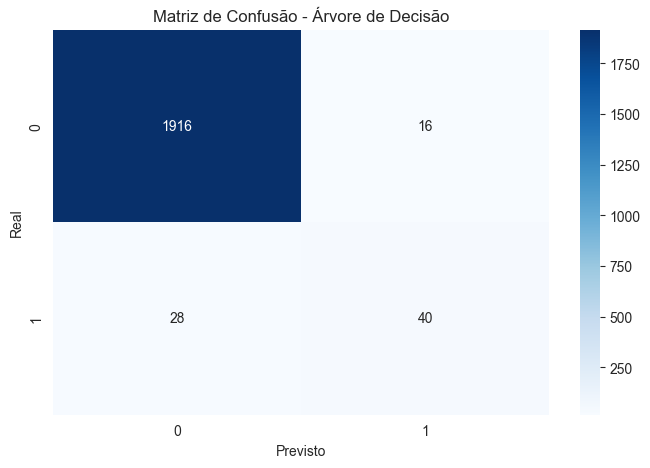

In [25]:
cm = confusion_matrix(y_test, best_y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title(f"Matriz de Confusão - {best_model_name}")
plt.xlabel("Previsto")
plt.ylabel("Real")
plt.show()

## 11. Relatório de Classificação do Melhor Modelo

In [26]:
print(f"Melhor modelo: {best_model_name}\n")
print(classification_report(y_test, best_y_pred, zero_division=0))

Melhor modelo: Árvore de Decisão

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1932
           1       0.71      0.59      0.65        68

    accuracy                           0.98      2000
   macro avg       0.85      0.79      0.82      2000
weighted avg       0.98      0.98      0.98      2000



## 12. Conclusão da Etapa

A etapa de modelagem permitiu comparar diferentes algoritmos de classificação para prever a ocorrência de falha da máquina. A partir das métricas calculadas, foi possível identificar o modelo com melhor desempenho para o problema proposto.

A escolha do melhor modelo foi baseada principalmente no F1-score, considerando o desbalanceamento da variável alvo. Os resultados obtidos indicam o potencial de aplicação de Machine Learning como apoio à manutenção preditiva industrial, permitindo transformar os dados operacionais em uma solução prática de detecção de falhas.